# Activity 3 — Naive Bayes for Spam Detection

## Cell 1 — Import Libraries

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

## Cell 2 — Load Dataset

In [103]:
train = pd.read_csv("TrainingData.csv", encoding='latin-1')
test = pd.read_csv("TestData.csv", encoding='latin-1')

print("Training Data Shape:")
print(train.shape)

print("\nTesting Data Shape:")
print(test.shape)

train.head()

Training Data Shape:
(3900, 2)

Testing Data Shape:
(1672, 1)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Cell 3 — Inspect Data

In [104]:
print(train.info())

print("\nMissing values:")
print(train.isnull().sum())

print("\nLabel counts:")
print(train['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    3900 non-null   object
 1   message  3900 non-null   object
dtypes: object(2)
memory usage: 61.1+ KB
None

Missing values:
label      0
message    0
dtype: int64

Label counts:
label
ham     3381
spam     519
Name: count, dtype: int64


## Cell 4 — Prepare Features and Labels

In [105]:
X_text = train['message']
y = train['label']

X_train_text, X_val_text, y_train, y_val = train_test_split(X_text, y, test_size=0.2, random_state=42)

## Cell 5 — Convert Text to Numerical Features

In [106]:
vectorizer = CountVectorizer()

X_train = vectorizer.fit_transform(X_train_text)
X_val = vectorizer.transform(X_val_text)

print("Vocabulary Size:")
print(len(vectorizer.vocabulary_))

Vocabulary Size:
6461


## Cell 6 — Train Naive Bayes Model

In [107]:
model = MultinomialNB()

model.fit(X_train, y_train)

print("Training completed")

Training completed


## Cell 7 — Evaluate on Validation Data

In [108]:
val_predictions = model.predict(X_val)

accuracy = accuracy_score(
    y_val,
    val_predictions
)

print("Accuracy:")
print(accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val,
        val_predictions
    )
)

Accuracy:
0.985897435897436

Classification Report:

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       687
        spam       0.95      0.94      0.94        93

    accuracy                           0.99       780
   macro avg       0.97      0.96      0.97       780
weighted avg       0.99      0.99      0.99       780



## Cell 8 — Confusion Matrix

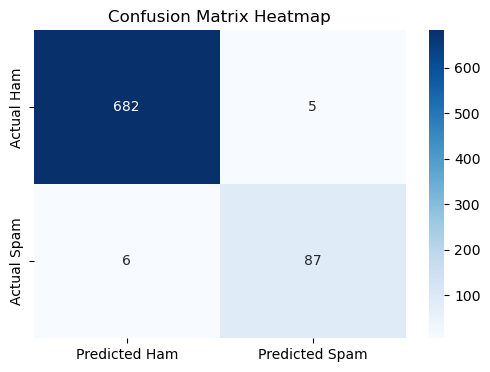

In [118]:
import seaborn as sns
cm = confusion_matrix(y_val, val_predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix Heatmap')
plt.show()

## Cell 9 — Predict TestData Messages

In [110]:
X_test = vectorizer.transform(
    test['message']
)

predictions = model.predict(X_test)

test['Predicted_Label']=predictions

test.head(20)

,message,Predicted_Label
0,That depends. How would you like to be treated...,ham
1,"Right on brah, see you later",ham
2,Waiting in e car 4 my mum lor. U leh? Reach ho...,ham
3,Your 2004 account for 07XXXXXXXXX shows 786 un...,spam
4,Do you want a new video handset? 750 anytime a...,spam
5,Went fast asleep dear.take care.,ham
6,No that just means you have a fat head,ham
7,Sounds like a plan! Cardiff is still here and ...,ham
8,Serious? What like proper tongued her,ham
9,She.s good. She was wondering if you wont say ...,ham


## Cell 10 — Save Predictions

In [111]:
test.to_csv(
    "Predictions.csv",
    index=False
)

print("Saved to Predictions.csv")

Saved to Predictions.csv


## Cell 11 — Manual Bayesian Formula Demonstration

In [112]:
print("Manual Bayes Formula Example")

print("""
Message:

Win free prize

Formula:

P(Spam|Message)
=
P(Spam)
\u00d7P(win|spam)
\u00d7P(free|spam)
\u00d7P(prize|spam)

Assume:

P(Spam)=0.13

P(win|spam)=0.40
P(free|spam)=0.45
P(prize|spam)=0.25
""")

spam_prob = (
    .13*
    .40*
    .45*
    .25
)

print("Spam probability:")
print(spam_prob)

ham_prob = (
    .87*
    .02*
    .01*
    .005
)

print("\nHam probability:")
print(ham_prob)

if spam_prob > ham_prob:
    print("\nPrediction: SPAM")
else:
    print("\nPrediction: HAM")

Manual Bayes Formula Example

Message:

Win free prize

Formula:

P(Spam|Message)
=
P(Spam)
×P(win|spam)
×P(free|spam)
×P(prize|spam)

Assume:

P(Spam)=0.13

P(win|spam)=0.40
P(free|spam)=0.45
P(prize|spam)=0.25

Spam probability:
0.005850000000000001

Ham probability:
8.7e-07

Prediction: SPAM


## Cell 12 — Test New Messages

In [113]:
new_messages = [

"Win a free prize now!",

"Meeting tomorrow at 10 AM",

"URGENT! Claim cash reward",

"Can you send the assignment later?",

"Free vacation tickets available"
]

new_vector = vectorizer.transform(
    new_messages
)

results = model.predict(
    new_vector
)

for msg,label in zip(
    new_messages,
    results
):
    print("Message:",msg)
    print("Prediction:",label)
    print()

Message: Win a free prize now!
Prediction: spam

Message: Meeting tomorrow at 10 AM
Prediction: ham

Message: URGENT! Claim cash reward
Prediction: spam

Message: Can you send the assignment later?
Prediction: ham

Message: Free vacation tickets available
Prediction: spam



## Cell 13 — Visualization (Spam vs Ham Word Frequency)

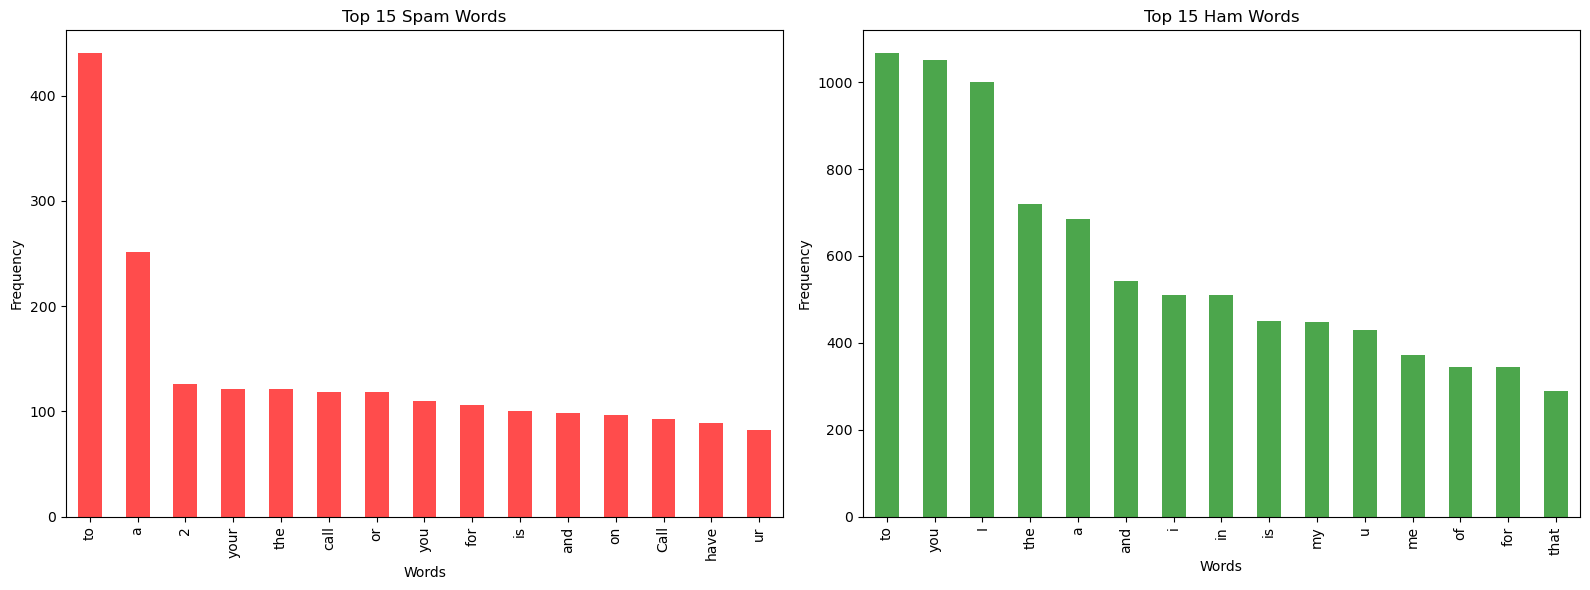

In [114]:
# Spam word frequency
spam_messages = train[train['label']=="spam"]['message']
spam_words = ' '.join(spam_messages).split()
spam_freq = pd.Series(spam_words).value_counts().head(15)

# Ham word frequency
ham_messages = train[train['label']=="ham"]['message']
ham_words = ' '.join(ham_messages).split()
ham_freq = pd.Series(ham_words).value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

spam_freq.plot(kind='bar', ax=axes[0], color='red', alpha=0.7)
axes[0].set_title('Top 15 Spam Words')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Frequency')

ham_freq.plot(kind='bar', ax=axes[1], color='green', alpha=0.7)
axes[1].set_title('Top 15 Ham Words')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Cell 14 — Conclusion Output

In [115]:
print("""

Conclusion

Naive Bayes successfully classified
messages as Spam and Ham.

The model used word frequency and
Bayesian probability to predict
message classes.

Future improvements:

1. TF-IDF
2. Remove stop words
3. Stemming
4. Larger dataset
5. Compare with SVM
6. Hyperparameter tuning

""")



Conclusion

Naive Bayes successfully classified
messages as Spam and Ham.

The model used word frequency and
Bayesian probability to predict
message classes.

Future improvements:

1. TF-IDF
2. Remove stop words
3. Stemming
4. Larger dataset
5. Compare with SVM
6. Hyperparameter tuning


